# Model Evaluation

Evaluate fitted spike models: convergence diagnostics, sparsity analysis,
replicate parameter correlations, global epistasis plots, and mutation
parameter export.

**Outline**
1. Load fitted models and training data
2. Convergence diagnostics
3. Shift sparsity analysis
4. Replicate parameter correlations
5. Global epistasis plots
6. Export mutations DataFrame and intermediate CSVs

In [1]:
import warnings

warnings.filterwarnings("ignore")

import os
import pickle
import sys

sys.path.insert(0, "notebooks")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import multidms.plot
from multidms.model_collection import ModelCollection

from _common import load_config, combine_replicate_muts

In [2]:
config_path = "config/config.yaml"
downstream_config_path = "config/config_downstream.yaml"
output_dir = None

In [3]:
# Parameters
config_path = "config/config.yaml"
downstream_config_path = "config/config_downstream.yaml"
output_dir = "results-prod-287-config-tier-split"


In [4]:
config = load_config(config_path, downstream_config_path)
spike = config["spike"]
fit_config = spike["fitting"]
lasso_choice = spike["lasso_choice"]
condition_titles = spike["condition_titles"]
condition_colors = spike["condition_colors"]
experiment_conditions = spike["experiment_conditions"]

if output_dir is None:
    output_dir = spike.get("output_dir", "results")

## Load data

In [5]:
with open(os.path.join(output_dir, "fit_collection.pkl"), "rb") as f:
    fit_collection_df = pickle.load(f)

func_score_df = pd.read_csv(
    os.path.join(output_dir, "training_functional_scores.csv")
).fillna({"aa_substitutions": ""})

model_collection = ModelCollection(fit_collection_df)
print(f"Loaded {len(fit_collection_df)} fitted models")
print(f"Loaded {len(func_score_df):,} training variants")

Loaded 18 fitted models
Loaded 303,007 training variants


## Convergence diagnostics

In [6]:
# Build summary table with fitted alpha and beta0 parameters
summary_rows = []
for _, row in model_collection.fit_models.iterrows():
    jm = row.model._jax_model
    r = {
        "dataset": row.dataset_name,
        "fusionreg": row.fusionreg,
        "converged": row.converged,
        "fit_time": row.fit_time,
    }
    # Alpha: shared scalar or per-condition dict
    if hasattr(jm.α, "items"):
        for cond in experiment_conditions:
            title = condition_titles.get(cond, cond)
            r[f"alpha_{title}"] = float(jm.α[cond])
    else:
        r["alpha"] = float(jm.α)
    # Per-condition loss
    for cond in experiment_conditions:
        loss_col = f"{cond}_loss_training"
        if loss_col in model_collection.fit_models.columns:
            r[f"loss_{condition_titles.get(cond, cond)}"] = row[loss_col]
    # Fitted beta0 per condition
    for cond in experiment_conditions:
        title = condition_titles.get(cond, cond)
        r[f"beta0_{title}"] = float(jm.φ[cond].β0)
    summary_rows.append(r)

summary_df = pd.DataFrame(summary_rows)
print(f"{summary_df['converged'].sum()}/{len(summary_df)} models converged\n")
summary_df.round(3)

18/18 models converged



,dataset,fusionreg,converged,fit_time,alpha,loss_Delta,loss_BA.1,loss_BA.2,beta0_Delta,beta0_BA.1,beta0_BA.2
0,rep_1,0.000,True,1032,15.555,0.225,0.229,0.229,-1.066,-1.069,-1.160
1,rep_1,0.000,True,937,15.323,0.225,0.230,0.231,-1.037,-1.042,-1.151
2,rep_1,0.000,True,1113,15.715,0.225,0.229,0.232,-1.079,-1.088,-1.168
3,rep_1,0.000,True,1134,15.662,0.228,0.229,0.238,-1.069,-1.082,-1.167
4,rep_1,0.000,True,572,14.400,0.237,0.233,0.255,-0.895,-0.922,-1.110
5,rep_1,0.000,True,427,13.428,0.272,0.236,0.285,-0.730,-0.794,-1.022
6,rep_1,0.000,True,464,12.023,0.374,0.234,0.330,-0.572,-0.652,-0.800
7,rep_1,0.000,True,506,11.734,0.462,0.233,0.371,-0.628,-0.625,-0.748
8,rep_1,0.001,True,562,11.335,0.475,0.233,0.404,-0.575,-0.571,-0.672
9,rep_2,0.000,True,1008,15.003,0.262,0.185,0.184,-1.010,-1.034,-1.161


In [7]:
conv_data = model_collection.convergence_trajectory_df(
    id_vars=("dataset_name", "fusionreg")
)
multidms.plot.convergence_trajectory(
    conv_data,
    id_cols=["dataset_name", "fusionreg"],
    title="Convergence trajectories",
)

alt.LayerChart(...)

## Shift sparsity

Fraction of shift parameters that are exactly zero, across the
regularization grid. Uses the `ModelCollection.shift_sparsity` method
which returns an interactive Altair chart faceted by dataset and
shift parameter.

In [8]:
sparsity_chart, sparsity_data = model_collection.shift_sparsity(return_data=True)
sparsity_chart

cache miss - this could take a moment


alt.FacetChart(...)

## Replicate parameter correlations

Correlation of mutation parameters (beta, shift) between replicates
across the regularization grid. Uses the `ModelCollection.mut_param_dataset_correlation`
method which returns an interactive Altair chart.

In [9]:
corr_chart, corr_data = model_collection.mut_param_dataset_correlation(
    return_data=True,
    times_seen_threshold=1,
)
corr_chart

cache miss - this could take a moment


alt.FacetChart(...)

## Global epistasis plots

Global epistasis (GE) landscape at the chosen lasso strength, showing
the fitted sigmoid mapping from latent to observed phenotype.

rep_1 (fusionreg=4e-05):


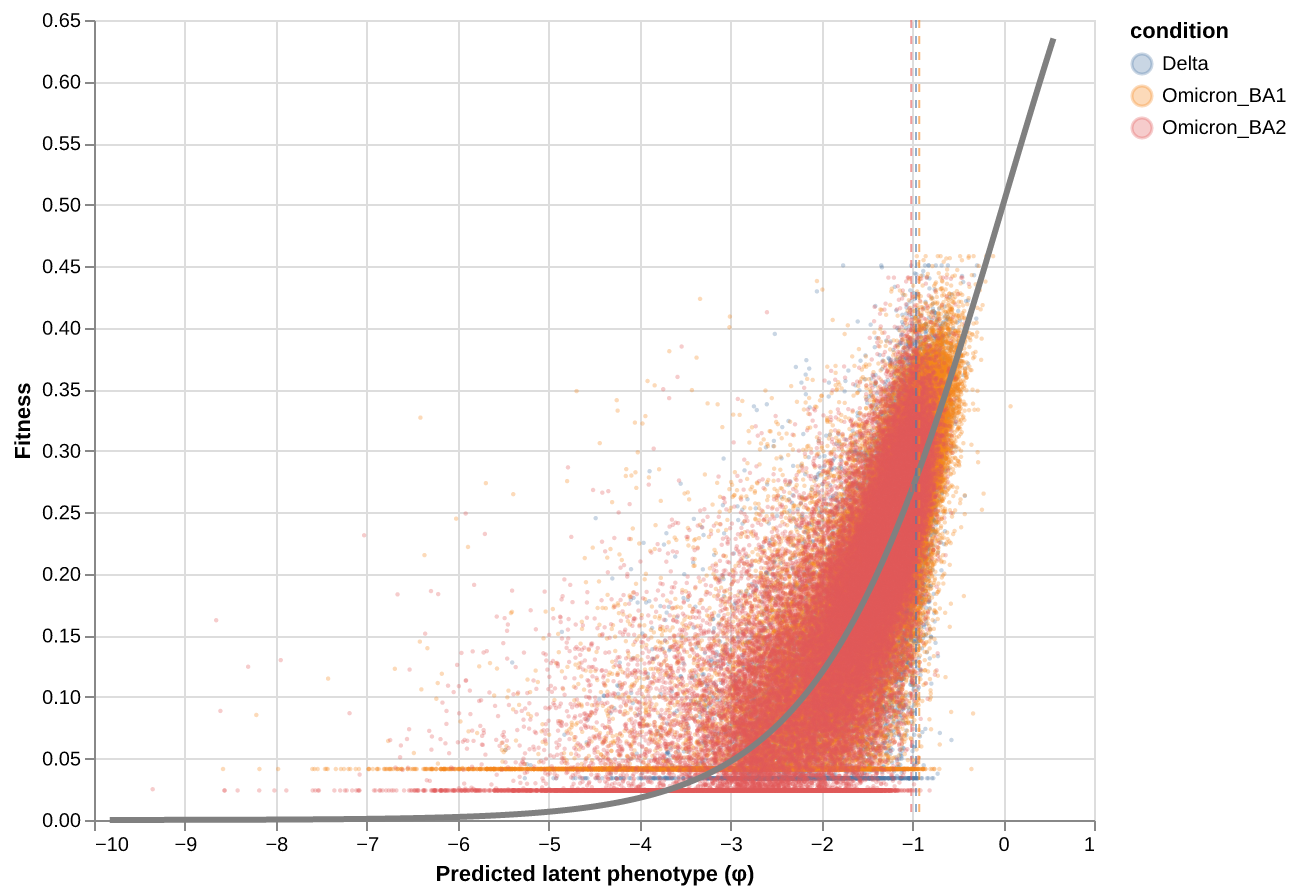

rep_2 (fusionreg=4e-05):


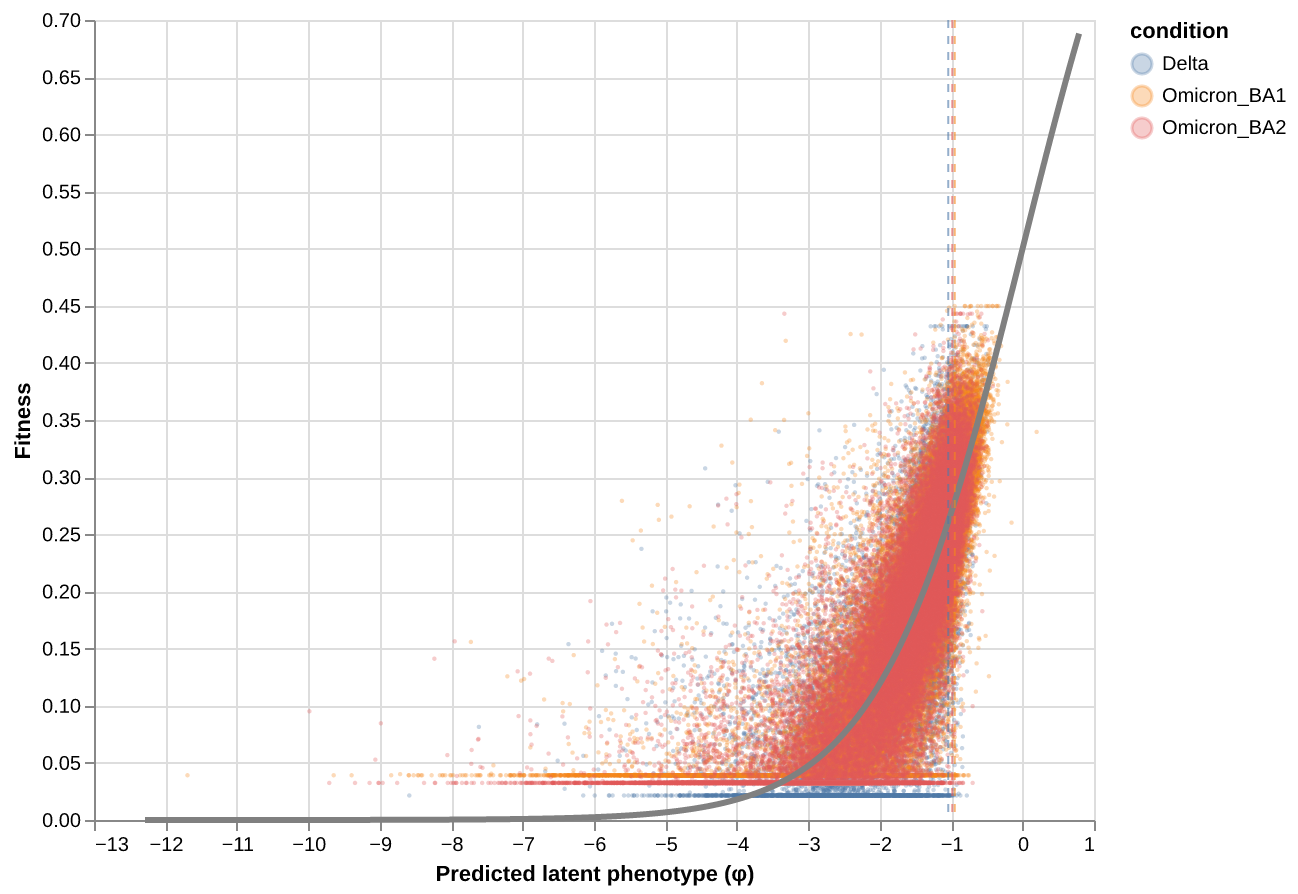

In [10]:
from IPython.display import display, Image
import tempfile

for ds_name in fit_collection_df["dataset_name"].unique():
    representative = (
        model_collection.fit_models
        .query(f"fusionreg == {lasso_choice} and dataset_name == '{ds_name}'")
    )
    if len(representative) == 0:
        print(f"No model at lasso={lasso_choice} for {ds_name}")
        continue
    model = representative.iloc[0].model
    print(f"{ds_name} (fusionreg={lasso_choice}):")
    chart = model.plot_ge_landscape()
    with tempfile.NamedTemporaryFile(suffix=".png") as tmp:
        chart.save(tmp.name, format="png", scale_factor=2)
        display(Image(filename=tmp.name))

## Export mutations DataFrame

Merge mutation parameters from both replicates at the chosen lasso strength.

In [11]:
fit_dict = {}
for _, row in model_collection.fit_models.query(
    f"fusionreg == {lasso_choice}"
).iterrows():
    fit_dict[row.dataset_name] = row.model

mutations_df = combine_replicate_muts(fit_dict, times_seen_threshold=1)

mutations_df["sense"] = np.where(
    mutations_df["muts"].str.contains("*", regex=False),
    "stop",
    "nonsynonymous",
)

print(f"mutations_df: {len(mutations_df):,} mutations")
print(f"  nonsynonymous: {(mutations_df['sense'] == 'nonsynonymous').sum():,}")
print(f"  stop: {(mutations_df['sense'] == 'stop').sum():,}")
mutations_df.head()

mutations_df: 5,809 mutations
  nonsynonymous: 5,654
  stop: 155


,mutation,wts,sites,muts,rep_1_beta_Delta,rep_2_beta_Delta,avg_beta_Delta,rep_1_beta_Omicron_BA1,rep_2_beta_Omicron_BA1,avg_beta_Omicron_BA1,rep_1_beta_Omicron_BA2,rep_2_beta_Omicron_BA2,avg_beta_Omicron_BA2,rep_1_shift_Delta,rep_2_shift_Delta,avg_shift_Delta,rep_1_shift_Omicron_BA2,rep_2_shift_Omicron_BA2,avg_shift_Omicron_BA2,sense
0,M1I,M,1,I,-1.029106,-1.692095,-1.360601,-1.538644,-1.692095,-1.615370,-1.538644,-1.696843,-1.617743,0.509537,0.000000,0.254769,0.000000,-0.004748,-0.002374,nonsynonymous
1,F2L,F,2,L,0.125301,0.129705,0.127503,0.149199,0.122698,0.135949,-0.067182,0.122698,0.027758,-0.023898,0.007006,-0.008446,-0.216382,0.000000,-0.108191,nonsynonymous
2,F2S,F,2,S,0.124667,0.250739,0.187703,0.124667,-0.044761,0.039953,0.125849,-0.044761,0.040544,0.000000,0.295500,0.147750,0.001182,0.000000,0.000591,nonsynonymous
3,F2V,F,2,V,0.004693,-0.031797,-0.013552,0.211634,-0.029317,0.091159,0.249183,0.000744,0.124964,-0.206942,-0.002480,-0.104711,0.037549,0.030061,0.033805,nonsynonymous
4,V3A,V,3,A,-0.069384,-0.047923,-0.058653,0.020125,-0.028629,-0.004252,-0.003258,-0.028629,-0.015943,-0.089509,-0.019294,-0.054401,-0.023383,0.000000,-0.011692,nonsynonymous


## Save outputs

In [12]:
groupby = ("dataset_name", "fusionreg")
collection_muts_df = model_collection.split_apply_combine_muts(
    groupby=groupby,
    times_seen_threshold=1,
)

mutations_df.to_csv(os.path.join(output_dir, "mutations_df.csv"), index=False)
print(f"Saved mutations_df.csv ({len(mutations_df):,} rows)")

collection_muts_df.to_csv(os.path.join(output_dir, "collection_muts.csv"), index=False)
print(f"Saved collection_muts.csv ({len(collection_muts_df):,} rows)")

sparsity_data.to_csv(os.path.join(output_dir, "fit_sparsity.csv"), index=False)
print(f"Saved fit_sparsity.csv ({len(sparsity_data)} rows)")

corr_data.to_csv(os.path.join(output_dir, "library_replicate_correlation.csv"), index=False)
print(f"Saved library_replicate_correlation.csv ({len(corr_data)} rows)")

Saved mutations_df.csv (5,809 rows)


Saved collection_muts.csv (112,635 rows)
Saved fit_sparsity.csv (72 rows)
Saved library_replicate_correlation.csv (72 rows)
